# USD Rates RV — Fitted-curve rich/cheap & signal backtest

Showcases `RVUtils.curve_fit_rv` (NSS cross-sectional rich/cheap on the UST CT curve) and `RVUtils.signal_backtest` (z-score strategy on a PCA-fly residual signal).

In [1]:
%matplotlib inline
import sys; sys.path.append("../../")
import datetime, pytz, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15, 6); plt.rcParams["axes.grid"] = True
from RVUtils.plt_timeseries import make_secondary_axis_plot

NYC = pytz.timezone("America/New_York")
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
ts = TimeseriesBuilder()
start = NYC.localize(datetime.datetime(2025, 6, 2, 17, 0))
end = NYC.localize(datetime.datetime(2026, 6, 17, 17, 0))
ROUTERS = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=False), "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=False)}
YRS = {"2y": 2, "3y": 3, "5y": 5, "7y": 7, "10y": 10, "20y": 20, "30y": 30}
MAT = {"CT2": 2, "CT3": 3, "CT5": 5, "CT7": 7, "CT10": 10, "CT20": 20, "CT30": 30}

def load(queries):
    return ts.get_timeseries(start=start, end=end, queries=queries, n_jobs=8, routers=ROUTERS)

def sofr(tenors):
    df = load([UnifiedQuery(curve="USD-SOFR-1D", tenor=t, value=UnifiedValue.IRS_RATE) for t in tenors])
    return df.rename(columns={f"USD-SOFR-1D {t} OUTRIGHT RATE": t for t in tenors})[list(tenors)]

def ust(cts):
    df = load([UnifiedQuery(cusip=c, value=UnifiedValue.FRB_YTM) for c in cts])
    return df.rename(columns={f"{c} OUTRIGHT YTM": c for c in cts})[list(cts)]

print("Setup OK. Window:", start.date(), "->", end.date())

Setup OK. Window: 2025-06-02 -> 2026-06-17


In [2]:
CTS = ["CT2","CT3","CT5","CT7","CT10","CT20","CT30"]
df_u = ust(CTS)
snap = pd.DataFrame({"id": CTS, "maturity": [MAT[c] for c in CTS], "yield": [df_u[c].iloc[-1] for c in CTS]})
snap

,id,maturity,yield
0,CT2,2,4.167000
1,CT3,3,4.184000
2,CT5,5,4.229000
3,CT7,7,4.336000
4,CT10,10,4.488393
5,CT20,20,4.937000
6,CT30,30,4.933104


### NSS fit of the latest UST CT curve — residual = rich/cheap

Cross-sectional fit RMSE: 0.49 bp


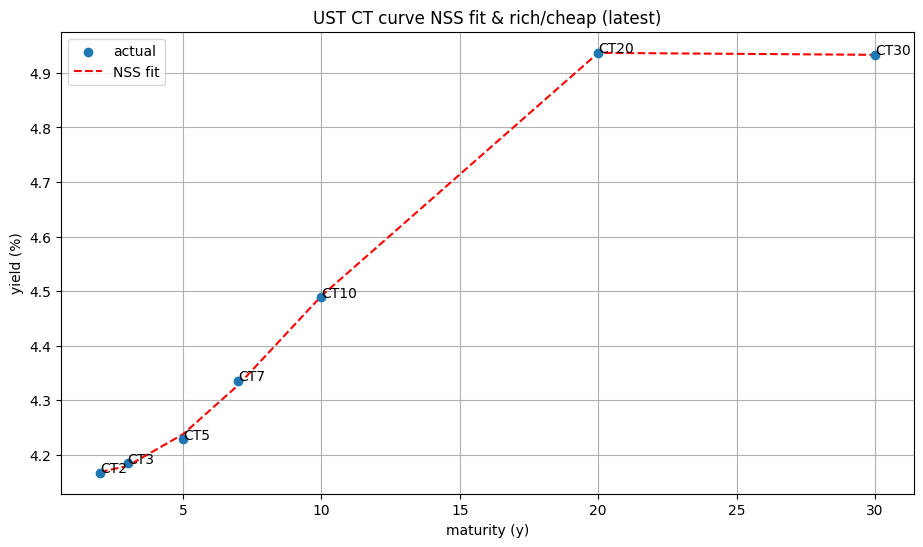

,id,maturity,yield,fitted,residual_bp
0,CT2,2,4.167000,4.168377,-0.14
1,CT3,3,4.184000,4.179452,0.45
2,CT5,5,4.229000,4.237664,-0.87
3,CT7,7,4.336000,4.327943,0.81
4,CT10,10,4.488393,4.491163,-0.28
5,CT20,20,4.937000,4.936755,0.02
6,CT30,30,4.933104,4.933143,-0.00


In [3]:
from RVUtils.curve_fit_rv import make_curve_fit_builder
fit, residual, rank, rmse, otr, getd = make_curve_fit_builder(snap, id_col="id", form="nss")
res_df = fit()
print("Cross-sectional fit RMSE:", round(rmse()*100, 2), "bp")
fig, axx = plt.subplots(figsize=(11,6))
axx.scatter(res_df["maturity"], res_df["yield"], zorder=3, label="actual")
order = res_df.sort_values("maturity")
axx.plot(order["maturity"], order["fitted"], "r--", label="NSS fit")
for _, r in res_df.iterrows(): axx.annotate(r["id"], (r["maturity"], r["yield"]))
axx.legend(); axx.set_xlabel("maturity (y)"); axx.set_ylabel("yield (%)")
axx.set_title("UST CT curve NSS fit & rich/cheap (latest)"); plt.show()
res_df.assign(residual_bp=(res_df["residual"]*100).round(2))[["id","maturity","yield","fitted","residual_bp"]]

### Rich/cheap ranking (most cheap first)

In [4]:
rank()[["id","residual"]].assign(residual_bp=lambda d: (d["residual"]*100).round(2))

,id,residual,residual_bp
rank,,,
1,CT7,0.008057,0.81
2,CT3,0.004548,0.45
3,CT20,0.000245,0.02
4,CT30,-0.000039,-0.00
5,CT2,-0.001377,-0.14
6,CT10,-0.002770,-0.28
7,CT5,-0.008664,-0.87


### Backtest: z-score strategy on the SOFR 2s5s10s PCA-fly residual

{'sharpe': np.float64(0.974), 't_stat': np.float64(0.991), 'hit_rate': 0.489, 'max_dd': -0.041, 'turnover': 10.621, 'avg_hold': 21.75, 'sharpe_net': np.float64(0.974)}


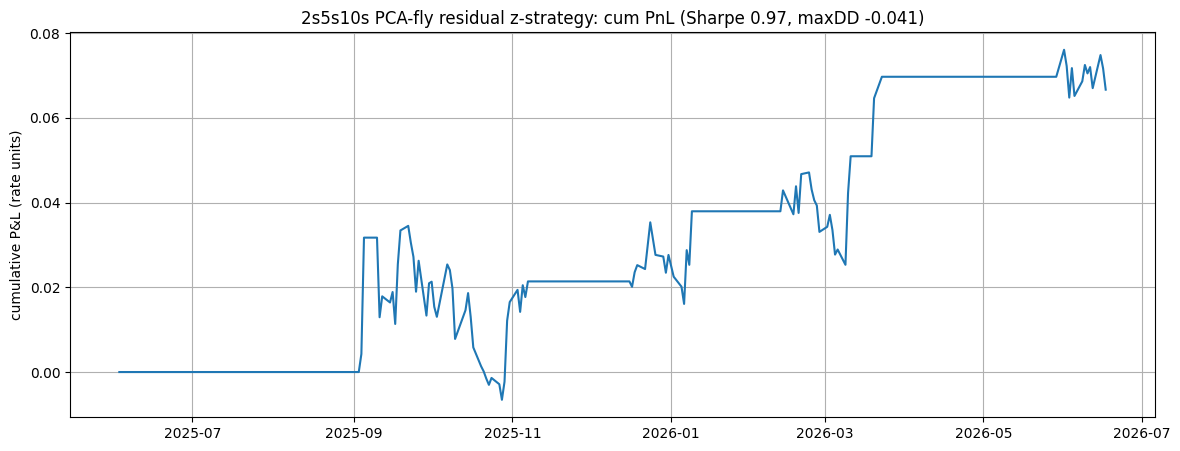

In [5]:
from RVUtils.pca_rv import make_pca_rv_builder
from RVUtils.signal_backtest import make_signal_backtest_builder
df_f = sofr(["2y","5y","10y"])
b = make_pca_rv_builder(df_f, on="levels", n_factors=2, sort_by_tenor=False)
b[0]()
w = b[3]("2y","5y","10y")
sig = b[2](("2y","5y","10y"), weights=w).series
forecast, zsig, position, pnl, stats_fn, ex_ante, fpt, gate, getd = make_signal_backtest_builder(sig)
pos = zsig(window=65, entry=1.5, exit=0.5, stop=4.0)
p = pnl(pos, cost_bps=0.0)
st = stats_fn(pos)
shp = st["sharpe"]; mdd = st["max_dd"]
print({k: round(v,3) for k,v in st.items()})
cum = p.cumsum()
fig, axx = plt.subplots(figsize=(14,5))
axx.plot(cum.index, cum.values)
axx.set_title(f"2s5s10s PCA-fly residual z-strategy: cum PnL (Sharpe {shp:.2f}, maxDD {mdd:.3f})")
axx.set_ylabel("cumulative P&L (rate units)"); plt.show()